In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os

#read all data files
print("Reading data from file...")
segment_status=pd.read_csv("segment_status.csv")
print("Reading data from file...")
segments=pd.read_csv("segments_refined.csv")
print("Reading data from file...")
streets=pd.read_csv("streets_refined.csv")
print("Reading data from file...")
nodes=pd.read_csv("nodes.csv")


Reading data from file...
Reading data from file...
Reading data from file...
Reading data from file...


In [3]:
#show some data per file
print("5 rows of segment_status")
display(segment_status.head())

print("5 rows of segments")
display(segments.head())

print("5 rows of streets")
display(streets.head())

print("5 rows of nodes")
display(nodes.head())

5 rows of segment_status


,_id,updated_at,segment_id,velocity
0,0,2020-07-03T14:55:31.869Z,24845,20
1,1,2020-07-03T15:02:56.048Z,33923,10
2,2,2020-07-04T08:15:52.696Z,33824,5
3,3,2020-07-04T08:15:59.903Z,33824,5
4,4,2020-07-04T08:16:08.201Z,33824,5


5 rows of segments


,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
0,0,2020-10-18T13:26:17.365Z,2020-10-18T13:26:17.365Z,373543511,5468660805,114,31096786,80.0,1,Quốc Lộ 1,trunk
1,1,2020-10-18T13:26:17.400Z,2020-10-18T13:26:17.400Z,5468660805,5738158916,9,31096786,80.0,1,Quốc Lộ 1,trunk
2,2,2020-10-18T13:26:17.435Z,2020-10-18T13:26:17.435Z,5738158916,5738158918,23,31096786,80.0,1,Quốc Lộ 1,trunk
3,3,2020-10-18T13:26:17.444Z,2020-10-18T13:26:17.444Z,5738158918,5738158912,66,31096786,80.0,1,Quốc Lộ 1,trunk
4,4,2020-10-18T13:26:17.452Z,2020-10-18T13:26:17.452Z,5738158912,5758104203,127,31096786,80.0,1,Quốc Lộ 1,trunk


5 rows of streets


,_id,level,max_velocity,name,type
0,31096786,1,80.0,Quốc Lộ 1,trunk
1,32575737,4,30.0,NaN,unclassified
2,32575794,4,30.0,Chu Văn An,unclassified
3,32575820,4,30.0,Nguyễn Văn Bá,tertiary
4,32575823,4,30.0,Nguyễn Thị Nhỏ,tertiary


5 rows of nodes


,_id,long,lat
0,366367223,106.629056,10.804243
1,366367233,106.709701,10.771110
2,366367242,106.737189,10.709337
3,366367274,106.760081,10.854489
4,366367285,106.721163,10.804994


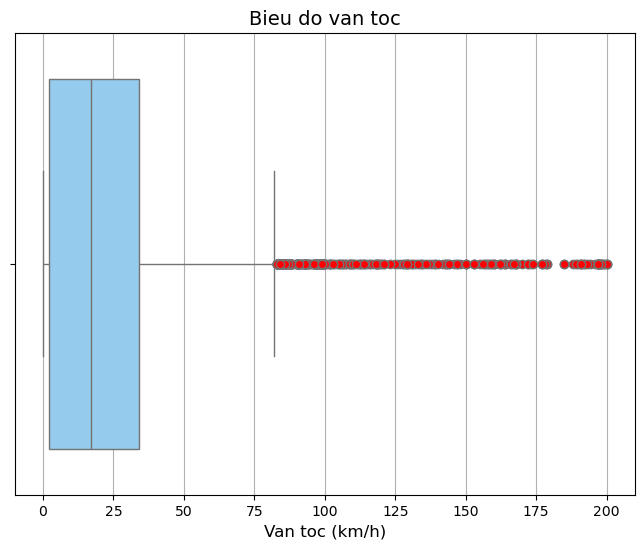

In [5]:
#check outers of segment_status
import matplotlib.pyplot as plt
import seaborn as sbn

plt.figure(figsize=(8,6))
sbn.boxplot(data=segment_status, x='velocity', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})

# Them tieu de va nhan truc
plt.title('Bieu do van toc', fontsize=14)
plt.xlabel('Van toc (km/h)', fontsize=12)

# Hien thi bieu do
plt.grid(axis='x', alpha=1)
plt.show()

In [7]:


#clear columns name
segment_status.columns=segment_status.columns.str.strip()
segments.columns=segments.columns.str.strip()
streets.columns=streets.columns.str.strip()
nodes.columns=nodes.columns.str.strip()

#merging data
#connect status and segment
segment_merged=pd.merge(
    segment_status,
    segments[['_id', 's_node_id', 'e_node_id', 'length', 'street_id']],
    left_on='segment_id',
    right_on='_id',
    suffixes=('_status','_segment')
)

#connect with street
final_merged=pd.merge(
    segment_merged,
    streets[['_id', 'level', 'max_velocity', 'name', 'type']],
    left_on="street_id",
    right_on="_id",
    how="left"
).drop(columns=['_id'])

display(final_merged.head())

#sort by update time
final_merged['updated_at']=pd.to_datetime(final_merged['updated_at'])
final_merged=final_merged.sort_values(by=['segment_id','updated_at']).reset_index(drop=True)

#export data train
os.makedirs("refined", exist_ok=True)
train_path = "refined/traffic_features_train.csv"
final_merged.to_csv(train_path, index=False, encoding="utf-8-sig")
print(f"-> Đã lưu dữ liệu TRAIN tại: {train_path} ({len(final_merged)} dòng)")

,_id_status,updated_at,segment_id,velocity,_id_segment,s_node_id,e_node_id,length,street_id,level,max_velocity,name,type
0,0,2020-07-03T14:55:31.869Z,24845,20,24845,2409410635,3771416347,73,138877181,2,50.0,Trường Chinh,primary
1,1,2020-07-03T15:02:56.048Z,33923,10,33923,5769406275,5769406276,78,213726584,4,30.0,Lạc Long Quân,tertiary
2,2,2020-07-04T08:15:52.696Z,33824,5,33824,2233730990,2299409160,67,213719139,4,30.0,NaN,unclassified
3,3,2020-07-04T08:15:59.903Z,33824,5,33824,2233730990,2299409160,67,213719139,4,30.0,NaN,unclassified
4,4,2020-07-04T08:16:08.201Z,33824,5,33824,2233730990,2299409160,67,213719139,4,30.0,NaN,unclassified


-> Đã lưu dữ liệu TRAIN tại: refined/traffic_features_train.csv (90938 dòng)


--- DANH SÁCH TOÀN BỘ 145 TUYẾN ĐƯỜNG PHÁT HIỆN CÓ LỖI TỐC ĐỘ ---


,name,Số record bị lỗi,Số record không lỗi,Tỷ lệ lỗi (%)
0,Lê Văn Sỹ,314,15,95.44
1,Lạc Long Quân,252,1993,11.22
2,Pasteur,186,142,56.71
3,Cao Thắng,112,94,54.37
4,Trần Quốc Thảo,88,90,49.44
5,Bình Thới,87,1038,7.73
6,Cống Quỳnh,75,140,34.88
7,Út Tịch,72,24,75.00
8,Lữ Gia,60,574,9.46
9,Ông Ích Khiêm,54,391,12.13


<Figure size 1000x600 with 0 Axes>

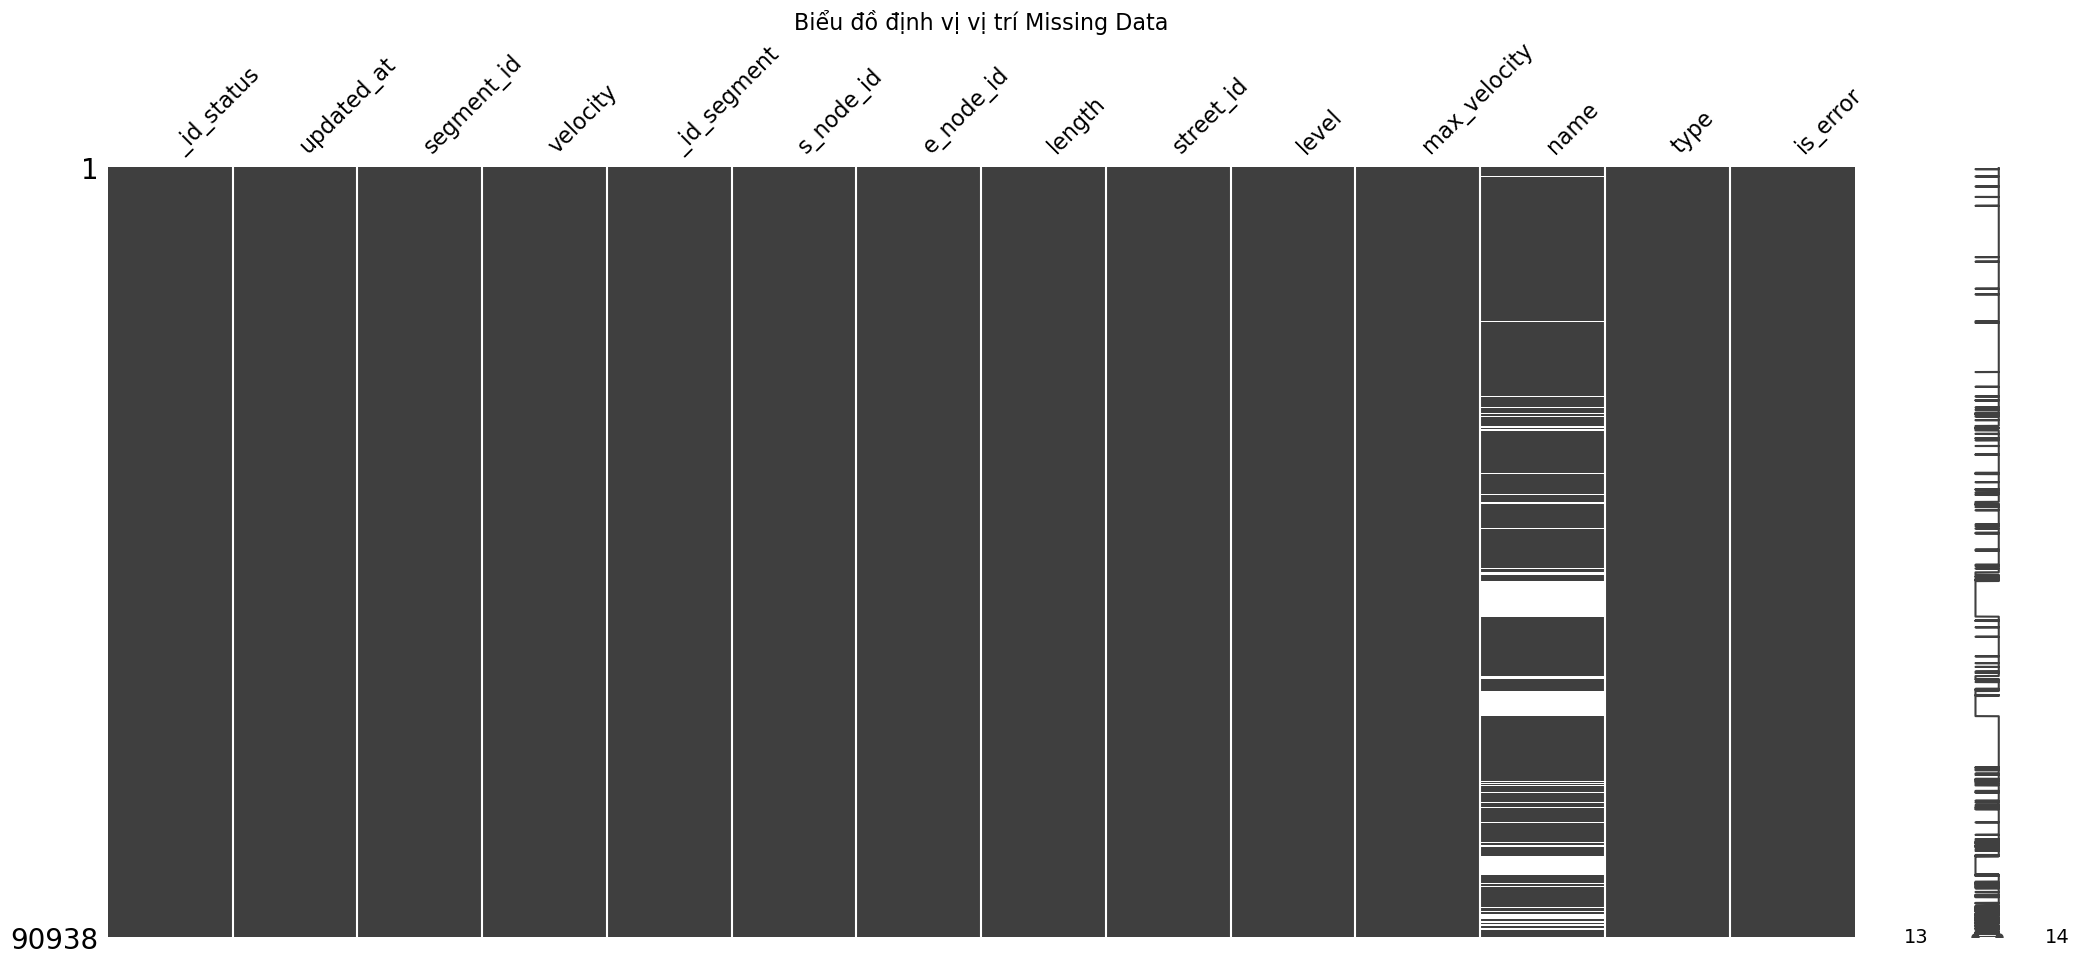

In [20]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# 1. Đảm bảo cột velocity đã được ép về dạng số
final_merged['velocity'] = pd.to_numeric(final_merged['velocity'], errors='coerce')

# 2. Tạo cột phụ đánh dấu dòng bị lỗi (1 nếu > 60, ngược lại là 0)
final_merged['is_error'] = (final_merged['velocity'] > 60).astype(int)

# 3. Gom cụm theo tên đường để tính toán các chỉ số
road_summary = final_merged.groupby('name')['is_error'].agg(
    Số_record_lỗi='sum',
    Tổng_số_record='count'
).reset_index()

# 4. Tính toán số dòng không lỗi và tỷ lệ phần trăm lỗi
road_summary['Số record không lỗi'] = road_summary['Tổng_số_record'] - road_summary['Số_record_lỗi']
road_summary['Tỷ lệ lỗi (%)'] = (road_summary['Số_record_lỗi'] / road_summary['Tổng_số_record'] * 100).round(2)
road_summary = road_summary.rename(columns={'Số_record_lỗi': 'Số record bị lỗi'})

# 5. MẤU CHỐT LỌC: Chỉ giữ lại các con đường THỰC SỰ BỊ LỖI (Số record lỗi > 0)
only_errors_summary = road_summary[road_summary['Số record bị lỗi'] > 0]

# Sắp xếp theo số lượng bản ghi lỗi giảm dần
only_errors_summary = only_errors_summary.sort_values(by='Số record bị lỗi', ascending=False).reset_index(drop=True)


# =================================================================
# CẤU HÌNH PHÒNG CHỐNG ẨN DÒNG (HIỂN THỊ 100% DANH SÁCH)
# =================================================================
# Bật chế độ hiển thị vô hạn số dòng (None nghĩa là không giới hạn)
pd.set_option('display.max_rows', None)

print(f"--- DANH SÁCH TOÀN BỘ {len(only_errors_summary)} TUYẾN ĐƯỜNG PHÁT HIỆN CÓ LỖI TỐC ĐỘ ---")
display(only_errors_summary[['name', 'Số record bị lỗi', 'Số record không lỗi', 'Tỷ lệ lỗi (%)']])

# Sau khi hiển thị xong, nên trả cấu hình Pandas về lại mặc định (ví dụ: hiển thị tối đa 60 dòng) 
# để tránh làm lag các ô code khác phía sau trong Notebook của bạn
pd.set_option('display.max_rows', 60)

plt.figure(figsize=(10, 6))
msno.matrix(final_merged)
plt.title("Biểu đồ định vị vị trí Missing Data", fontsize=16)
plt.show()

In [41]:
#prepare for draw map
#merge to get the start position of node
data_map = pd.merge(
    final_merged,
    nodes[['_id', 'long', 'lat']],
    left_on='s_node_id',
    right_on='_id',
    how='left'
)
data_map = data_map.rename(columns={'long': 'long_start', 'lat': 'lat_start'})
data_map = data_map.drop(columns=['_id_y'], errors='ignore') # avoid duplicate

#merge to get the end position of node
data_final_map = pd.merge(
    data_map,
    nodes[['_id', 'long', 'lat']],
    left_on='e_node_id',
    right_on='_id',
    how='left'
)
data_final_map = data_final_map.rename(columns={'long': 'long_end', 'lat': 'lat_end'})

columns_to_drop = ['_id_x', '_id_y', '_id','_id_segment']
for col in columns_to_drop:
    if col in data_final_map.columns:
        data_final_map = data_final_map.drop(columns=[col])
        
display(data_final_map.head())

#export map
map_path = "refined/traffic_spatial_map.csv"
data_final_map.to_csv(map_path, index=False, encoding="utf-8-sig")
print(f"-> Đã lưu dữ liệu VẼ MAP tại: {map_path} ({len(data_final_map)} dòng)")
print("\nHoàn thành gộp dữ liệu cấu trúc đồ thị giao thông thành công!")

,_id_status,updated_at,segment_id,velocity,s_node_id,e_node_id,length,street_id,level,max_velocity,name,type,long_start,lat_start,long_end,lat_end
0,89252,2021-04-16 00:55:31.333000+00:00,26,117,366428456,366416066,116,32575820,4,30.0,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422
1,892,2020-08-02 23:56:28.019000+00:00,33,34,366469460,3792257828,26,32575862,3,40.0,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
2,4501,2020-08-02 23:59:28.137000+00:00,33,26,366469460,3792257828,26,32575862,3,40.0,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
3,8110,2020-08-03 00:02:28.070000+00:00,33,2,366469460,3792257828,26,32575862,3,40.0,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
4,11719,2020-08-03 00:05:28.204000+00:00,33,35,366469460,3792257828,26,32575862,3,40.0,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808


-> Đã lưu dữ liệu VẼ MAP tại: refined/traffic_spatial_map.csv (90938 dòng)

Hoàn thành gộp dữ liệu cấu trúc đồ thị giao thông thành công!


In [21]:
%pip install folium


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [45]:
import os
import folium
import pandas as pd

print("=== BƯỚC 1: NẠP DỮ LIỆU KHÔNG GIAN BẢN ĐỒ ===")
df_map = pd.read_csv("refined/traffic_spatial_map.csv")

# Ép kiểu thời gian linh hoạt (tránh lỗi định dạng hỗn hợp dòng 356)
df_map['updated_at'] = pd.to_datetime(df_map['updated_at'], format='mixed')

# =================================================================
# GIẢI PHÁP TỐI ƯU MẬT ĐỘ: Tính giá trị trung bình theo từng Đoạn đường
# =================================================================
print("Đang tính toán mật độ tổng hợp mạng lưới giao thông toàn thành phố...")
# Nhóm theo segment_id để lấy trung bình vận tốc thực tế, tọa độ của mỗi đoạn đường
df_snapshot = df_map.groupby('segment_id').mean(numeric_only=True).reset_index()

# Khôi phục lại cột Tên đường ('name') bị mất sau phép toán toán học .mean()
name_lookup = df_map.groupby('segment_id')['name'].first().to_dict()
df_snapshot['name'] = df_snapshot['segment_id'].map(name_lookup)

print(f"-> Tổng số lượng đoạn đường thực tế sẽ hiển thị lên bản đồ: {len(df_snapshot)}")

print("=== BƯỚC 2: KHỞI TẠO BẢN ĐỒ NỀN TP.HCM ===")
# Điểm đặt tâm tại Quận 1, Zoom 12 để bao quát diện rộng, dùng nền tối giản 'cartodbpositron'
mymap = folium.Map(location=[10.762622, 106.660172], zoom_start=12, tiles="cartodbpositron")

# === BƯỚC 3: ĐỊNH NGHĨA HÀM PHÂN PHỐI MÀU GIAO THÔNG ===
def determine_color(row):
    velo = row['velocity']
    max_velo = row['max_velocity']
    
    if pd.isna(velo) or pd.isna(max_velo) or max_velo == 0:
        return "gray"  # Màu xám nếu thiếu dữ liệu tính toán
        
    ratio = velo / max_velo
    if ratio < 0.4: 
        return "red"      # Kẹt xe nghiêm trọng
    elif ratio < 0.7: 
        return "orange"   # Xe di chuyển chậm, ùn ứ nhẹ
    return "green"        # Đường thông thoáng

print("=== BƯỚC 4: TIẾN HÀNH QUÉT VÀ VẼ MẠNG LƯỚI ĐỒ THỊ GIAO THÔNG ===")
# Bạn có thể tăng giảm số lượng vẽ bằng .head(N) nếu máy quá lag. Để trống sẽ vẽ toàn bộ bản đồ.
for idx, row in df_snapshot.iterrows():
    try:
        # Đảm bảo không dòng nào bị khuyết vị trí định vị không gian
        if pd.notna(row['lat_start']) and pd.notna(row['lat_end']):
            start_point = [row['lat_start'], row['long_start']]
            end_point = [row['lat_end'], row['long_end']]
            
            # Lấy màu sắc trực quan tương ứng
            line_color = determine_color(row)
            
            # Tạo nét vẽ đường thẳng nối điểm đầu và cuối
            folium.PolyLine(
                locations=[start_point, end_point],
                color=line_color,
                weight=4,         # Độ dày của vạch giao thông
                opacity=0.8,      # Độ hiển thị sắc nét của nét vẽ
                popup=f"Đường: {row['name']} | Vận tốc TB: {round(row['velocity'], 1)} km/h (Giới hạn: {row['max_velocity']})"
            ).add_to(mymap)
            
    except Exception as e:
        # Bỏ qua các dòng lỗi đơn lẻ để luồng vẽ chính chạy liên tục không bị dừng code
        continue

print("=== BƯỚC 5: XUẤT BẢN ĐỒ RA FILE HTML ===")
os.makedirs("refined", exist_ok=True)
output_html = "refined/hochiminh_traffic_map.html"
mymap.save(output_html)

print(f"\n[THÀNH CÔNG] Bản đồ giao thông đã được sinh ra!")
print(f"Vui lòng truy cập thư mục và click đúp vào file: '{output_html}' để thưởng thức kết quả trên trình duyệt web.")

=== BƯỚC 1: NẠP DỮ LIỆU KHÔNG GIAN BẢN ĐỒ ===
Đang tính toán mật độ tổng hợp mạng lưới giao thông toàn thành phố...
-> Tổng số lượng đoạn đường thực tế sẽ hiển thị lên bản đồ: 10027
=== BƯỚC 2: KHỞI TẠO BẢN ĐỒ NỀN TP.HCM ===
=== BƯỚC 4: TIẾN HÀNH QUÉT VÀ VẼ MẠNG LƯỚI ĐỒ THỊ GIAO THÔNG ===
=== BƯỚC 5: XUẤT BẢN ĐỒ RA FILE HTML ===

[THÀNH CÔNG] Bản đồ giao thông đã được sinh ra!
Vui lòng truy cập thư mục và click đúp vào file: 'refined/hochiminh_traffic_map.html' để thưởng thức kết quả trên trình duyệt web.
